In [1]:
#7.1

import numpy as np
from numpy import linalg as la

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)
det = la.det(A)
print(f'det = {det}')

b = np.array([2,2,-1])
inv = la.inv(A)
xyz = inv@b
print(f'x, y, z = {xyz}')
print()

tran = A.T
print(A@tran)   #not orthogonal
print()

lam, v = la.eig(A)
print(f'eigenvalues = {lam}')

det = 1.0
x, y, z = [10. -1. -2.]

[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]

eigenvalues = [ 1.         -4.79128785 -0.20871215]


In [2]:
#7.3

import numpy as np
from numpy import linalg as la
from math import cos, sin, radians

def Ex(angle):
    ang = radians(angle)
    ex = np.array([1,0,0,0,cos(ang),sin(ang),0,-sin(ang),cos(ang)])
    ex = ex.reshape(3,3)
    return ex

def Ey(angle):
    ang = radians(angle)
    ey = np.array([cos(ang),0,-sin(ang),0,1,0,sin(ang),0,cos(ang)])
    ey = ey.reshape(3,3)
    return ey
    
def Ez(angle):
    ang = radians(angle)
    ez = np.array([cos(ang),sin(ang),0,-sin(ang),cos(ang),0,0,0,1])
    ez = ez.reshape(3,3)
    return ez

E = Ez(57)@Ey(62.6)@Ez(192.25)
print(E)
print()

A = np.array([1,0,0])
rot = E@A
print(rot)   #???
print()

lam, v = la.eig(E)
print(lam.reshape(3,1))
print()

ra = radians(192.25)
dec = radians(27.4)

r = np.array([cos(dec)*cos(ra),cos(dec)*sin(ra),sin(dec)]).reshape(3,1)
print(r)
norm = la.norm(r)
print(f'norm = {norm}')
print()

rot2 = E@r
print(rot2.round())

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

[-0.06698874  0.49272847 -0.86760081]

[[-0.52856796+0.84889099j]
 [-0.52856796-0.84889099j]
 [ 1.        +0.j        ]]

[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
norm = 1.0

[[0.]
 [0.]
 [1.]]


coefficients = [[ 2.18582332e+02]
 [-5.51003146e+02]
 [ 5.65812237e+02]
 [-3.13633556e+02]
 [ 1.04544074e+02]
 [-2.19331360e+01]
 [ 2.91867715e+00]
 [-2.39059756e-01]
 [ 1.09925609e-02]
 [-2.17117476e-04]]


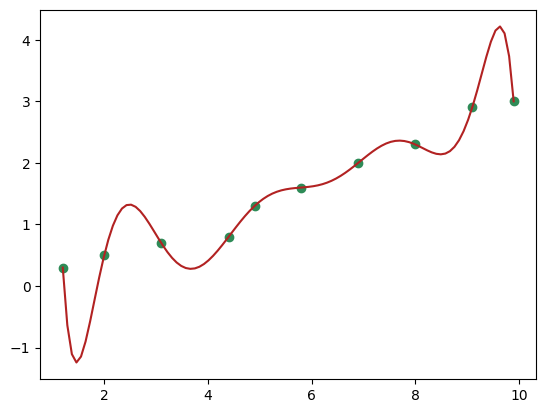

In [3]:
#7.5

import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import figure, show

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)
A = np.array([])
for i in range(n):
    X = x[i]
    B = np.array([])
    for j in range(n):
        b = X**j
        B = np.append(B,b)
    A = np.append(A,B)
    
A = A.reshape(n,n)
y = y.reshape(n,1)

a = la.solve(A,y)
print(f'coefficients = {a}')

fig = figure()
frame = fig.add_subplot()
frame.scatter(x,y,color='seagreen')

xval = np.linspace(min(x),max(x),100)
yval = np.array([])
c = 0
for i in range(len(a)):
    c += a[i]*(xval**i)

yval = np.append(yval,c)

frame.plot(xval,yval,color='firebrick')

show()

0.5


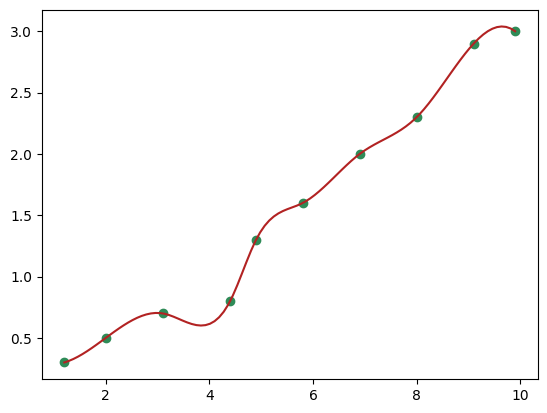

In [26]:
#7.6

import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

fig = figure()
frame = fig.add_subplot()
frame.scatter(x,y,color='seagreen')

xval = np.linspace(1.2,9.9,100)
yval = f(xval)

frame.plot(xval,yval,color='firebrick')

show()

In [38]:
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

class Interpolation:
    def __init__(self,x,y):
        self.x = x
        self.y = y
        self.xval = np.linspace(min(self.x),max(self.x),100)
        
        #linear
        self.f_lin = ip.interp1d(x, y, kind='slinear')
        
        #other splines
        self.f_quad = ip.interp1d(x, y, kind='quadratic')
        self.f_cub = ip.interp1d(x, y, kind='cubic')
        
        #polynomial
        n = len(self.x)
        A = np.array([])
        for i in range(n):
            X = self.x[i]
            B = np.array([])
            for j in range(n):
                b = X**j
                B = np.append(B,b)
            A = np.append(A,B)
        A = A.reshape(n,n)
        y = self.y.reshape(n,1)
        self.a = la.solve(A,y)
    
    def linear(self):
        yval = self.f_lin(self.xval)
        return self.xval,yval
    
    def quadratic(self):
        yval = self.f_quad(self.xval)
        return self.xval,yval
    
    def cubic(self):
        yval = self.f_cub(self.xval)
        return self.xval,yval
    
    def polynomial(self):
        yval = np.array([])
        c = 0
        for i in range(len(self.a)):
            c += self.a[i]*(self.xval**i)
        yval = np.append(yval,c)
        return self.xval,yval
    
    def user(self):
        user = int(input('Give an X value: '))
        if user < min(self.x) or user > max(self.x):
            raise Exception('X value out of range')
        func = input('Interpolation function: ')
        if func == 'Linear':
            Y = self.f_lin(user)
        elif func == 'Polynomial':
            Y = 0
            for i in range(len(self.a)):
                Y += self.a[i]*(user**i)
        elif func == 'Quadratic':
            Y = self.f_quad(user)
        elif func == 'Cubic':
            Y = self.f_cub(user)
        return Y
    
idk = Interpolation(x,y)
xval, yval = idk.polynomial()

#fig = figure()
#frame = fig.add_subplot()
#frame.plot(xval,yval)

#show()

idk.user()

Give an X value: 2
Interpolation function: Linear


array(0.5)

In [40]:
#7.7

import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i, j={row_y}, {col_x} => x, y={col_x}, {row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i, j=0.7, 0.2 => x, y=0.2, 0.7 is 2.658000


====== LEASTSQ RESULTS ==========
Params:                          [69.93792316 64.13233859]

====== CURVE_FIT RESULTS ==========
Params:                          [ 9.18949276 71.38296246]


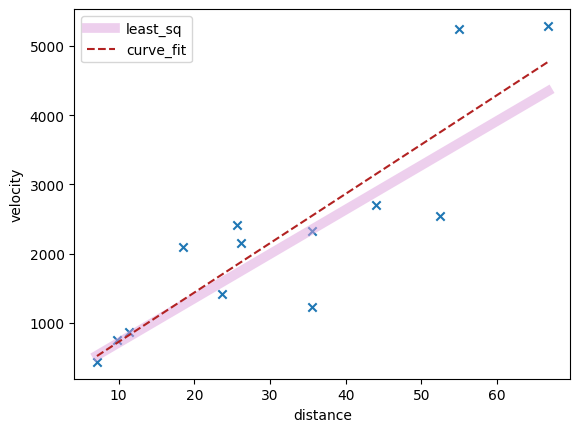

In [66]:
#7.10

import numpy as np
from matplotlib.pyplot import figure, show
from scipy.optimize import leastsq, curve_fit

data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

#data unpacking
distance = np.asarray(data[::4])
dis_error = np.asarray(data[2::4])
velocity = np.asarray(data[1::4])
vel_error = np.asarray(data[3::4])

fig = figure()
frame = fig.add_subplot()
frame.scatter(distance, velocity, marker = 'x')

X = np.array([distance.min(),distance.max()])


#LEASTSQ

def model1(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

def residuals(beta, x, y, sigy):
    return (y - model1(beta,x))/sigy

beta_start = [0, 50.0]          # Initial estimates for beta0 and beta1
data = (distance, velocity, vel_error)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta1, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

print( "====== LEASTSQ RESULTS ==========")
print( "Params:                         ", beta1)
print()

Y = model1(beta1, X)

frame.plot(X,Y,color='plum',label='least_sq',linewidth=7,alpha=0.5)


#CURVEFIT

def model2(x, beta0, beta1):
    return beta0 + beta1*x

# Do the fitting
beta2, pcov = curve_fit(model2, distance, velocity)#, sigma = vel_error)

print( "====== CURVE_FIT RESULTS ==========")
print( "Params:                         ", beta2)

Y = model2(X, beta2[0], beta2[1])

frame.plot(X,Y,color='firebrick',label='curve_fit',linestyle='dashed')


frame.legend()
frame.set_xlabel('distance')
frame.set_ylabel('velocity')
show()